In [12]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf
import pandas_ta as ta
data = yf.download(tickers = 'TSLA', start = '2012-03-11',end = '2022-07-10')
data.columns = data.columns.droplevel(1)
data.head(5)

C:\Users\fardi\AppData\Local\Temp\ipykernel_4176\1951641807.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers = 'TSLA', start = '2012-03-11',end = '2022-07-10')
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2012-03-12,2.400667,2.419333,2.306667,2.312667,29449500
2012-03-13,2.406000,2.439333,2.366667,2.434000,15024000
2012-03-14,2.352667,2.400000,2.320000,2.400000,12772500
2012-03-15,2.333333,2.365333,2.318667,2.352000,8574000
2012-03-16,2.354667,2.392667,2.322000,2.326667,10939500


In [13]:
# Adding indicators
data['RSI']=ta.rsi(data['Close'], length=15)
data['EMAF']=ta.ema(data['Close'], length=20)
data['EMAM']=ta.ema(data['Close'], length=100)
data['EMAS']=ta.ema(data['Close'], length=150)

data['Target'] = data['Close'] - data['Open']
data['Target'] = data['Target'].shift(-1)

data['TargetClass'] = [1 if data.Target[i]>0 else 0 for i in range(len(data))]

data['TargetNextClose'] = data['Close'].shift(-1)

data.dropna(inplace=True)
data.reset_index(inplace = True)
data.drop(['Volume', 'Close', 'Date'], axis=1, inplace=True)

C:\Users\fardi\AppData\Local\Temp\ipykernel_4176\1362440897.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data['TargetClass'] = [1 if data.Target[i]>0 else 0 for i in range(len(data))]


In [14]:
data_set = data.iloc[:, 0:11]#.values
pd.set_option('display.max_columns', None)

data_set.head(20)

Price,High,Low,Open,RSI,EMAF,EMAM,EMAS,Target,TargetClass,TargetNextClose
0,1.932000,1.883333,1.929333,45.204905,1.937943,2.016706,2.074058,-0.045333,0,1.842667
1,1.915333,1.833333,1.888000,41.980709,1.928869,2.013260,2.070993,-0.046000,0,1.822000
2,1.870000,1.790667,1.868000,40.567397,1.918691,2.009472,2.067695,0.026000,1,1.870667
3,1.872667,1.822667,1.844667,45.220347,1.914117,2.006724,2.065085,0.038000,1,1.921333
4,1.922667,1.853333,1.883333,49.619896,1.914804,2.005033,2.063181,-0.063334,0,1.869333
5,1.932667,1.852000,1.932667,45.593288,1.910474,2.002346,2.060614,-0.006000,0,1.849333
6,1.880000,1.820000,1.855333,44.117959,1.904651,1.999316,2.057815,-0.009333,0,1.856667
7,1.866667,1.824000,1.866000,44.819491,1.900081,1.996491,2.055151,0.067334,1,1.892667
8,1.904000,1.824667,1.825333,48.237080,1.899375,1.994435,2.052999,-0.073333,0,1.828000
9,1.901333,1.816667,1.901333,43.099588,1.892577,1.991139,2.050019,-0.018666,0,1.834667


In [15]:
from sklearn.preprocessing import MinMaxScaler
sc = MinMaxScaler(feature_range=(0,1))
data_set_scaled = sc.fit_transform(data_set)
print(data_set_scaled)

C:\Users\fardi\anaconda3\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


[[1.90641740e-04 2.29441495e-04 2.53878496e-04 ... 5.98706547e-01
  0.00000000e+00 5.06359380e-05]
 [1.50250907e-04 1.05641235e-04 1.52978952e-04 ... 5.98698558e-01
  0.00000000e+00 0.00000000e+00]
 [4.03908333e-05 0.00000000e+00 1.04156198e-04 ... 5.99560903e-01
  1.00000000e+00 1.19238497e-04]
 ...
 [5.60516339e-01 5.30796607e-01 5.39918334e-01 ... 6.10667637e-01
  1.00000000e+00 5.63303842e-01]
 [5.63949502e-01 5.58082183e-01 5.58910401e-01 ... 7.26485205e-01
  1.00000000e+00 5.94689510e-01]
 [5.90122195e-01 5.70520025e-01 5.66575579e-01 ... 7.00215705e-01
  1.00000000e+00 6.09929083e-01]]


In [16]:
# multiple feature from data provided to the model
X = []
#print(data_set_scaled[0].size)
#data_set_scaled=data_set.values
backcandles = 30
print(data_set_scaled.shape[0])
for j in range(8):#data_set_scaled[0].size):#2 columns are target not X
    X.append([])
    for i in range(backcandles, data_set_scaled.shape[0]):#backcandles+2
        X[j].append(data_set_scaled[i-backcandles:i, j])

#move axis from 0 to position 2
X=np.moveaxis(X, [0], [2])

#Erase first elements of y because of backcandles to match X length
#del(yi[0:backcandles])
#X, yi = np.array(X), np.array(yi)
# Choose -1 for last column, classification else -2...
X, yi =np.array(X), np.array(data_set_scaled[backcandles:,-1])
y=np.reshape(yi,(len(yi),1))
#y=sc.fit_transform(yi)
#X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
print(X)
print(X.shape)
print(y)
print(y.shape)

2449
[[[1.90641740e-04 2.29441495e-04 2.53878496e-04 ... 1.12105704e-04
   1.13246059e-04 5.98706547e-01]
  [1.50250907e-04 1.05641235e-04 1.52978952e-04 ... 1.01305012e-04
   1.03266478e-04 5.98698558e-01]
  [4.03908333e-05 0.00000000e+00 1.04156198e-04 ... 8.94356236e-05
   9.25277386e-05 5.99560903e-01]
  ...
  [9.16045368e-04 8.96314706e-04 8.51145035e-04 ... 9.24670402e-05
   3.61124234e-05 5.98874225e-01]
  [8.12648672e-04 7.98923279e-04 8.49516562e-04 ... 1.00631549e-04
   4.00643189e-05 5.99385236e-01]
  [7.27019978e-04 7.85718863e-04 7.68146470e-04 ... 1.09213589e-04
   4.43663972e-05 5.99265466e-01]]

 [[1.50250907e-04 1.05641235e-04 1.52978952e-04 ... 1.01305012e-04
   1.03266478e-04 5.98698558e-01]
  [4.03908333e-05 0.00000000e+00 1.04156198e-04 ... 8.94356236e-05
   9.25277386e-05 5.99560903e-01]
  [4.68539214e-05 7.92321071e-05 4.71969004e-05 ... 8.08214968e-05
   8.40301759e-05 5.99704626e-01]
  ...
  [8.12648672e-04 7.98923279e-04 8.49516562e-04 ... 1.00631549e-04
   4.

In [17]:
# split data into train test sets
splitlimit = int(len(X)*0.8)
print(splitlimit)
X_train, X_test = X[:splitlimit], X[splitlimit:]
y_train, y_test = y[:splitlimit], y[splitlimit:]
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)
print(y_train)

1935
(1935, 30, 8)
(484, 30, 8)
(1935, 1)
(484, 1)
[[0.0009637 ]
 [0.00103884]
 [0.00106007]
 ...
 [0.238095  ]
 [0.23842168]
 [0.23809828]]


In [18]:
from keras.models import Sequential
from keras.layers import LSTM
from keras.layers import Dropout
from keras.layers import Dense
from keras.layers import TimeDistributed

import tensorflow as tf
import keras
from keras import optimizers
from keras.callbacks import History
from keras.models import Model
from keras.layers import Dense, Dropout, LSTM, Input, Activation, concatenate
import numpy as np
#tf.random.set_seed(20)
np.random.seed(10)

lstm_input = Input(shape=(backcandles, 8), name='lstm_input')
inputs = LSTM(150, name='first_layer')(lstm_input)
inputs = Dense(1, name='dense_layer')(inputs)
output = Activation('linear', name='output')(inputs)
model = Model(inputs=lstm_input, outputs=output)
adam = optimizers.Adam()
model.compile(optimizer=adam, loss='mse')
model.fit(x=X_train, y=y_train, batch_size=15, epochs=30, shuffle=True, validation_split = 0.1)

Epoch 1/30
117/117 ━━━━━━━━━━━━━━━━━━━━ 16s 37ms/step - loss: 9.6810e-04 - val_loss: 7.0656e-04
Epoch 2/30
117/117 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - loss: 9.2351e-06 - val_loss: 6.0257e-04
Epoch 3/30
117/117 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 8.5627e-06 - val_loss: 7.0190e-04
Epoch 4/30
117/117 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 5.0749e-06 - val_loss: 5.6380e-04
Epoch 5/30
117/117 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 5.4996e-06 - val_loss: 4.5236e-04
Epoch 6/30
117/117 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 4.8775e-06 - val_loss: 6.0000e-04
Epoch 7/30
117/117 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 6.1286e-06 - val_loss: 4.2726e-04
Epoch 8/30
117/117 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 6.8359e-06 - val_loss: 3.7437e-04
Epoch 9/30
117/117 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - loss: 6.4439e-06 - val_loss: 5.6901e-04
Epoch 10/30
117/117 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - loss: 6.9679e-06 - val_loss: 4.3535e-04
Epoch 11/30
117/117 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms

In [19]:
y_pred = model.predict(X_test)
#y_pred=np.where(y_pred > 0.43, 1,0)
for i in range(10):
    print(y_pred[i], y_test[i])

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step
[0.21535663] [0.23884311]
[0.2157252] [0.23282078]
[0.21554999] [0.22724437]
[0.21409266] [0.22002803]
[0.21149316] [0.24948956]
[0.2100015] [0.26030917]
[0.21542044] [0.26516198]
[0.22218883] [0.29536834]
[0.23164344] [0.30377216]
[0.23865543] [0.30237398]


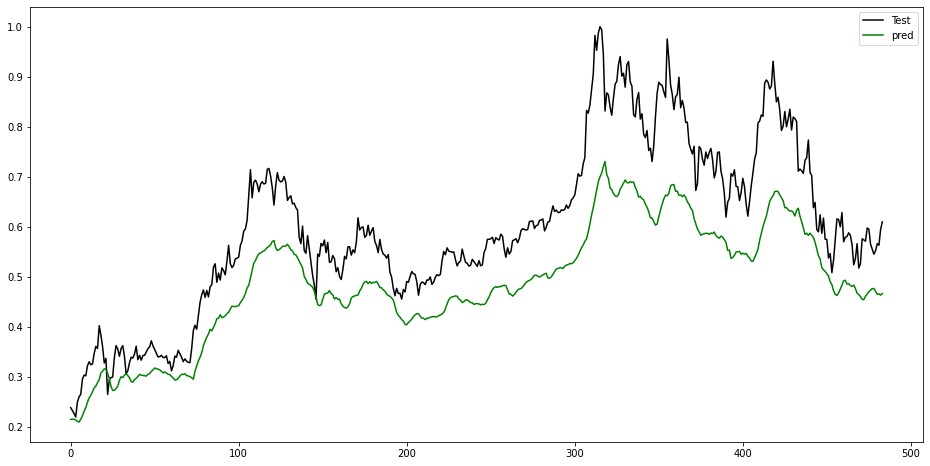

In [20]:
plt.figure(figsize=(16,8))
plt.plot(y_test, color = 'black', label = 'Test')
plt.plot(y_pred, color = 'green', label = 'pred')
plt.legend()
plt.show()